In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

# 加载数据集
diamonds = pd.read_csv('diamonds.csv')

# 选择三个特征
features = ['price', 'carat', 'depth']
df = diamonds[features].copy()

# 计算偏度
skewness = df.skew()
print("偏度：")
print(skewness)

# 判断哪些需要变换（|偏度| > 0.5 视为需要变换）
need_transform = skewness[abs(skewness) > 0.5]
print("\n需要变换的特征：")
print(need_transform)

偏度：
price    1.618395
carat    1.116646
depth   -0.082294
dtype: float64

需要变换的特征：
price    1.618395
carat    1.116646
dtype: float64


In [3]:
# 准备 X 和 y
X = df[['carat', 'depth']]   # 使用 carat 和 depth 作为特征
y = np.log(df['price'])      # 预测对数价格

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 定义两个 Pipeline
pipe_no_transform = Pipeline([
    ('ridge', Ridge())
])

pipe_yj = Pipeline([
    ('yj', PowerTransformer(method='yeo-johnson')),  # 同时作用于 carat 和 depth
    ('ridge', Ridge())
])

# 交叉验证比较
cv_scores_no = cross_val_score(pipe_no_transform, X_train, y_train, cv=5, scoring='r2')
cv_scores_yj = cross_val_score(pipe_yj, X_train, y_train, cv=5, scoring='r2')

print(f"无变换 R²: mean={cv_scores_no.mean():.4f}, std={cv_scores_no.std():.4f}")
print(f"Yeo-Johnson R²: mean={cv_scores_yj.mean():.4f}, std={cv_scores_yj.std():.4f}")

无变换 R²: mean=0.8472, std=0.0041
Yeo-Johnson R²: mean=0.9359, std=0.0012


C:\Users\a\AppData\Local\Temp\ipykernel_4552\1695882960.py:16: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a\AppData\Local\Temp\ipykernel_4552\1695882960.py:16: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a\AppData\Local\Temp\ipykernel_4552\1695882960.py:16: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a\AppData\Local\Temp\ipykernel_4552\1695882960.py:16: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\Collage\python\Python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Collage\python\Python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

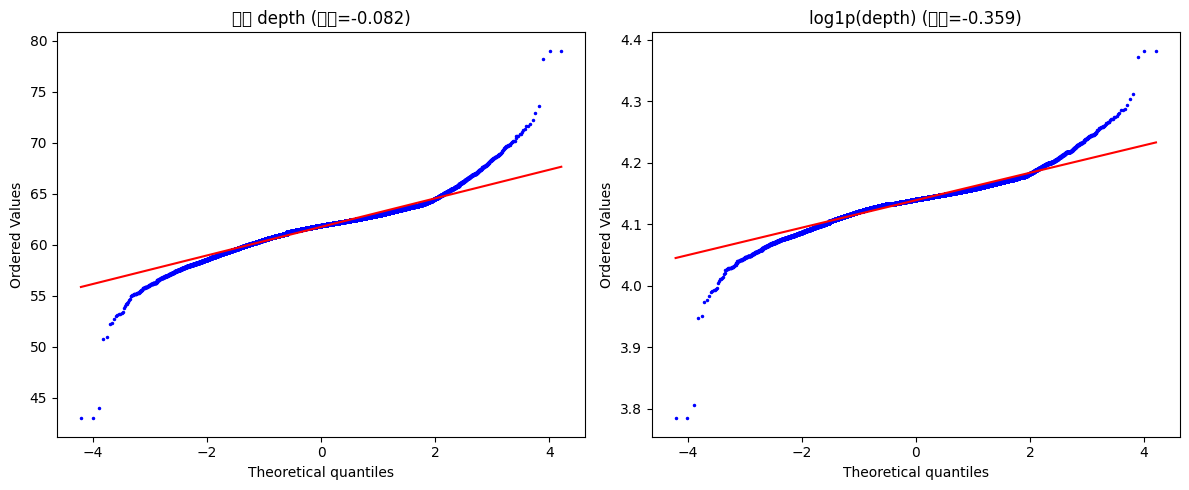

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 原始 depth
stats.probplot(df['depth'], dist='norm', plot=axes[0])
axes[0].set_title(f"原始 depth (偏度={df['depth'].skew():.3f})")
axes[0].get_lines()[0].set_marker('.')
axes[0].get_lines()[0].set_markersize(3)

# log1p 变换后
depth_log1p = np.log1p(df['depth'])
stats.probplot(depth_log1p, dist='norm', plot=axes[1])
axes[1].set_title(f"log1p(depth) (偏度={stats.skew(depth_log1p):.3f})")
axes[1].get_lines()[0].set_marker('.')
axes[1].get_lines()[0].set_markersize(3)

plt.tight_layout()
plt.show()

In [5]:
class SkewnessSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.5, method='yeo-johnson'):
        self.threshold = threshold
        self.method = method
        self.pt_ = None
        self.selected_cols_ = None

    def fit(self, X, y=None):
        # 确保 X 是 DataFrame
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        skewness = X.skew()
        self.selected_cols_ = skewness[abs(skewness) > self.threshold].index.tolist()
        if self.selected_cols_:
            self.pt_ = PowerTransformer(method=self.method)
            self.pt_.fit(X[self.selected_cols_])
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        X_trans = X.copy()
        if self.selected_cols_:
            transformed = self.pt_.transform(X[self.selected_cols_])
            # 将变换后的列替换回 DataFrame
            for i, col in enumerate(self.selected_cols_):
                X_trans[col] = transformed[:, i]
        return X_trans.values  # 返回 numpy 数组供 pipeline 使用

# 测试 SkewnessSelector
from sklearn.preprocessing import StandardScaler

pipe_skew = Pipeline([
    ('skew_sel', SkewnessSelector(threshold=0.5, method='yeo-johnson')),
    ('ridge', Ridge())
])

# 使用 carat 和 depth，其中 carat 偏度>0.5，depth 偏度<0.5
X_all = df[['carat', 'depth']]
cv_scores_skew = cross_val_score(pipe_skew, X_train, y_train, cv=5, scoring='r2')
print(f"SkewnessSelector 管道 R²: mean={cv_scores_skew.mean():.4f}, std={cv_scores_skew.std():.4f}")

SkewnessSelector 管道 R²: mean=0.9359, std=0.0013
